In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

In [4]:
df.shape

(50000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [6]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [7]:
df.isnull().sum().sort_values(ascending = False)

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3500
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Days_Since_Last_Purchase         3000
Pages_Per_Session                3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
Gender                              0
Average_Order_Value                 0
Total_Purchases                     0
Cart_Abandonment_Rate               0
Login_Frequency                     0
Membership_Years                    0
City                                0
Lifetime_Value                      0
Country                             0
Churned                             0
Signup_Quarter                      0
dtype: int64

In [8]:
cols = ['Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Session_Duration_Avg', 'Pages_Per_Session']

for col in cols:
    df[col].fillna(df[col].median())

In [9]:
df['Credit_Balance'].dtype

dtype('float64')

In [10]:
df['Credit_Balance'] = pd.to_numeric(df['Credit_Balance'], errors = 'coerce')

In [11]:
df['Credit_Balance'].fillna(df['Credit_Balance'].median())

0        2278.0
1        3028.0
2        2317.0
3        2674.0
4        5354.0
          ...  
49995    3499.0
49996    3154.0
49997    1622.0
49998    2634.0
49999     612.0
Name: Credit_Balance, Length: 50000, dtype: float64

In [12]:
cols = ['Returns_Rate', 'Discount_Usage_Rate', 'Email_Open_Rate']

for col in cols:
    df[col].fillna(df[col].median())

In [13]:
df['Wishlist_Items'].fillna(0)
df['Product_Reviews_Written'].fillna(0)
df['Customer_Service_Calls'].fillna(0)

0        9.0
1        7.0
2        4.0
3        2.0
4        1.0
        ... 
49995    5.0
49996    5.0
49997    4.0
49998    5.0
49999    7.0
Name: Customer_Service_Calls, Length: 50000, dtype: float64

In [14]:
df['Days_Since_Last_Purchase'].fillna(df['Days_Since_Last_Purchase'].max())

0        34.0
1        71.0
2        11.0
3        47.0
4        73.0
         ... 
49995    18.0
49996    48.0
49997     7.0
49998    72.0
49999    37.0
Name: Days_Since_Last_Purchase, Length: 50000, dtype: float64

In [15]:
df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].median())

0        1.0
1        3.0
2        2.0
3        3.0
4        4.0
        ... 
49995    1.0
49996    4.0
49997    1.0
49998    3.0
49999    1.0
Name: Payment_Method_Diversity, Length: 50000, dtype: float64

In [16]:
df['Age'].fillna(df['Age'].median())

0        43.0
1        36.0
2        45.0
3        56.0
4        35.0
         ... 
49995    38.0
49996    37.0
49997    44.0
49998    41.0
49999    56.0
Name: Age, Length: 50000, dtype: float64

In [17]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [18]:
df.isnull().sum().sort_values(ascending = False)

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3500
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Days_Since_Last_Purchase         3000
Pages_Per_Session                3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
Gender                              0
Average_Order_Value                 0
Total_Purchases                     0
Cart_Abandonment_Rate               0
Login_Frequency                     0
Membership_Years                    0
City                                0
Lifetime_Value                      0
Country                             0
Churned                             0
Signup_Quarter                      0
dtype: int64

In [19]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].median())

In [20]:
df.isnull().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

In [21]:
df.isna().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

In [22]:
(df == "").sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

# Churn Distribution

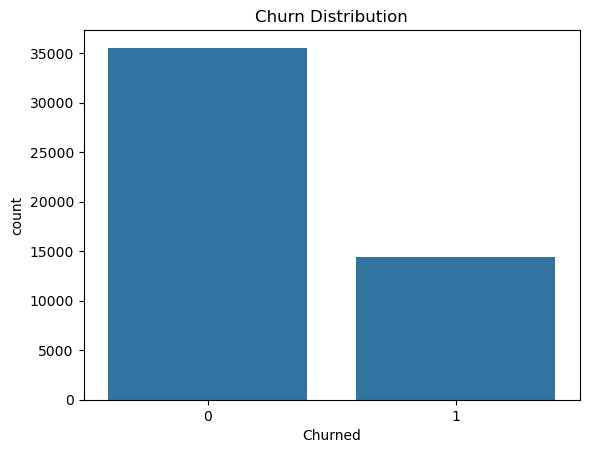

In [23]:
sns.countplot(x = 'Churned', data = df)
plt.title('Churn Distribution')
plt.show()

# Age vs Churn

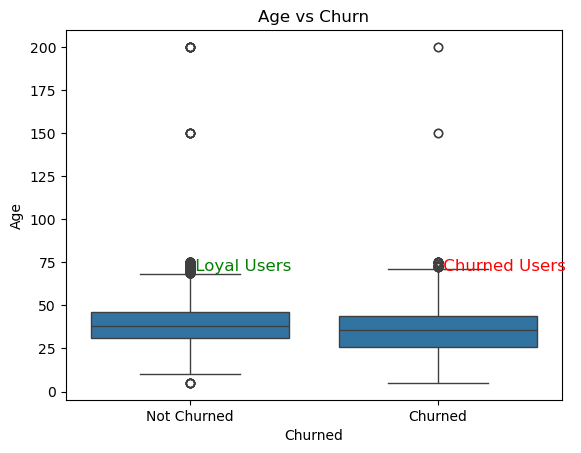

In [24]:
sns.boxplot(x = 'Churned', y = 'Age', data = df)

plt.text(0, 70, " Loyal Users ",   fontsize = 12, color = 'green')
plt.text(1, 70, " Churned Users ", fontsize = 12, color = 'red')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.title('Age vs Churn')
plt.show()

# Credit Balance vs Churn

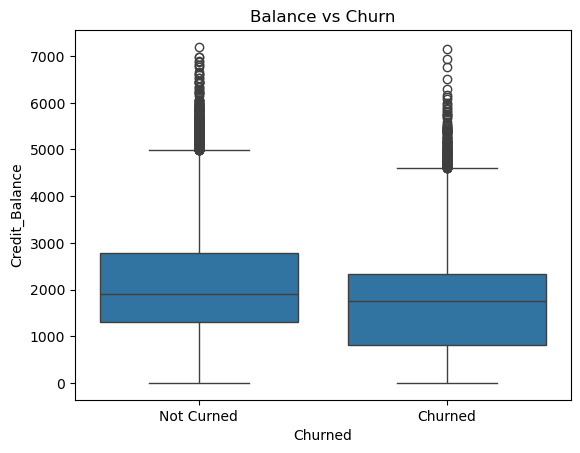

In [25]:
sns.boxplot(x = 'Churned', y = 'Credit_Balance', data = df)
plt.title('Balance vs Churn')
plt.xticks([0, 1], ['Not Curned', 'Churned'])
plt.show()

# Engagement vs Churn

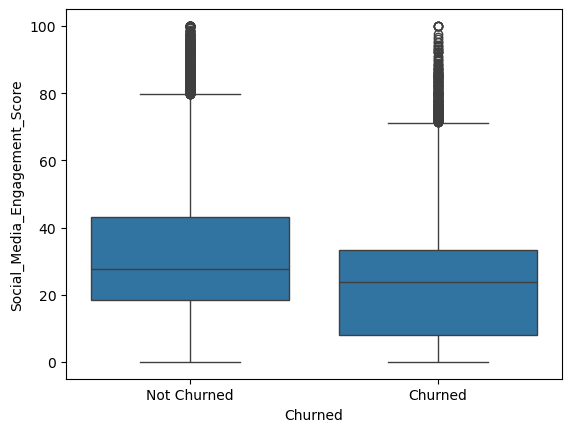

In [26]:
sns.boxplot(x = 'Churned', y = 'Social_Media_Engagement_Score', data = df)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

# 
Day Since Last Purchase

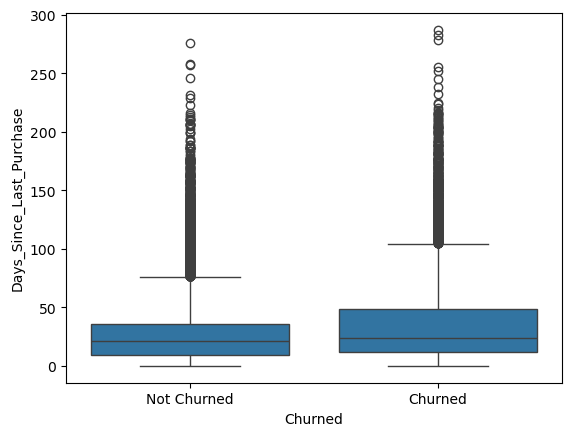

In [27]:
sns.boxplot(x = 'Churned', y = 'Days_Since_Last_Purchase', data =df)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

# Discount Usage vs Churn

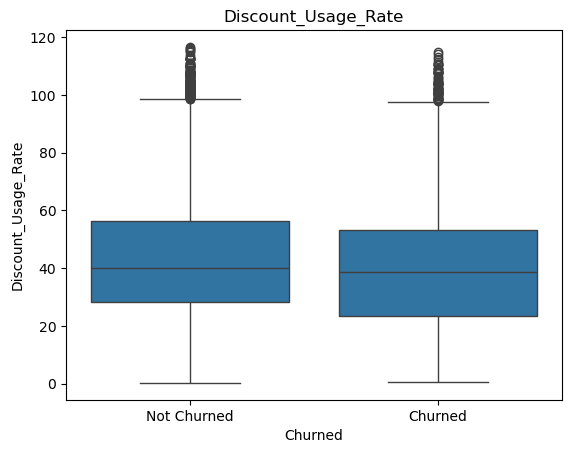

In [28]:
sns.boxplot(x = 'Churned', y = 'Discount_Usage_Rate', data = df)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.title('Discount_Usage_Rate')
plt.show()

# City wise churn

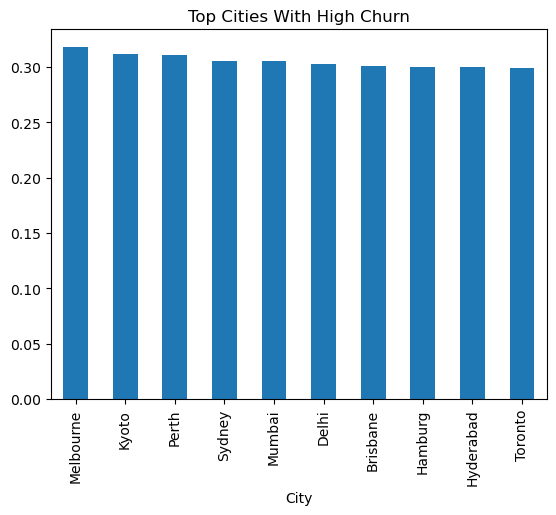

In [29]:
df.groupby('City')['Churned'].mean().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Top Cities With High Churn')
plt.show()

# High Value Customers

In [30]:
threshold = df['Lifetime_Value'].quantile(0.75)
df['High_Value_Customer'] = (df['Lifetime_Value'] >= threshold).astype(int)

In [31]:
df.High_Value_Customer.head(30)

0     0
1     0
2     0
3     1
4     1
5     1
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    1
21    0
22    1
23    1
24    1
25    0
26    0
27    0
28    1
29    0
Name: High_Value_Customer, dtype: int64

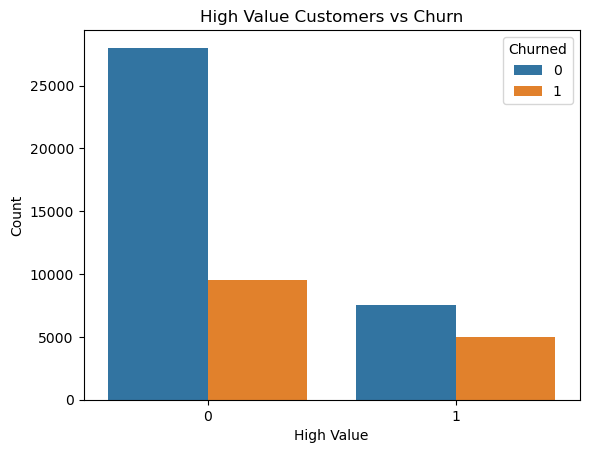

In [32]:
sns.countplot(x = 'High_Value_Customer', hue = 'Churned', data = df)
plt.title('High Value Customers vs Churn')
plt.xlabel('High Value')
plt.ylabel('Count')
plt.show()

# Feature Engineering

# RFM (Recency, Frequency, Monetary)

# Engagement Score

In [33]:
df['Engagement_score'] = (
    df['Login_Frequency'] +
    df['Pages_Per_Session'] +
    df['Session_Duration_Avg']
)

# More Engagement less churn

# Purchase Power

In [34]:
df['Purchase_Power'] = df['Total_Purchases'] * df['Average_Order_Value']
# Detect High Value Customer

# Recency Feature

In [35]:
df['Recency_Score'] = 1 / (df['Days_Since_Last_Purchase'] + 1)
# Recent Activity = less churn

# Discount Sensitivity

In [36]:
df['Discount_sensitivity'] = df['Discount_Usage_Rate'] * df['Total_Purchases']
# Customers whose only buy when discount is available

# Activity Ratio

In [37]:
df['Activity_Ratio'] = df['Login_Frequency'] / (df['Membership_Years'] + 1)

# Customer Value Segment

In [38]:
df['Customer_Value'] = df['Lifetime_Value'] / (df['Total_Purchases'] + 1)

# Interaction Features

In [39]:
df['Engagement_Per_Purchase'] = df['Engagement_score'] / (df['Total_Purchases'] + 1)

# Drop Unnecessary columns

In [40]:
df.drop(['Customer_ID'], axis = 1, errors = 'ignore', inplace = True)

# Encoding (Categorical -> Numeric)

In [41]:
df = pd.get_dummies(df, drop_first = True)

# Feature & Target

In [42]:
X = df.drop('Churned', axis = 1)
y = df['Churned']

# Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# Check Infinity values

In [44]:
import numpy as np
np.isinf(X_train).sum()

Age                     0
Membership_Years        0
Login_Frequency         0
Session_Duration_Avg    0
Pages_Per_Session       0
                       ..
City_Vancouver          0
City_Yokohama           0
Signup_Quarter_Q2       0
Signup_Quarter_Q3       0
Signup_Quarter_Q4       0
Length: 79, dtype: int64

# Replace infinity to NaN

In [45]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imputation

In [46]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scaling

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test =  scaler.transform(X_test)

# Train Models

# Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000)    # max_iter = 1000 times iteration
lr.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Accuracy / Evaluation

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print('Accuracy Score:', accuracy_score(Y_test, y_pred) * 100)
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Accuracy Score: 91.29
[[6940  190]
 [ 681 2189]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7130
           1       0.92      0.76      0.83      2870

    accuracy                           0.91     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.91      0.91      0.91     10000



# Threshold Tuning  = 0.5

In [51]:
y_proba = rf.predict_proba(X_test)[:,1]

# change threshold
y_pred = (y_proba > 0.3).astype(int)

In [52]:
rf = RandomForestClassifier(class_weight = 'balanced')
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Accuracy / Evaluation

In [53]:
print(accuracy_score(Y_test, y_pred))
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

0.8817
[[6349  781]
 [ 402 2468]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      7130
           1       0.76      0.86      0.81      2870

    accuracy                           0.88     10000
   macro avg       0.85      0.88      0.86     10000
weighted avg       0.89      0.88      0.88     10000



# Feature Importance

In [54]:
feature_names = X.columns

importance = pd.Series(
    rf.feature_importances_,
    index = feature_names
)

importance.sort_values(ascending=False).head(10)

Customer_Service_Calls    0.115514
Cart_Abandonment_Rate     0.074847
Age                       0.061348
Lifetime_Value            0.053891
Engagement_score          0.040463
Email_Open_Rate           0.038681
Discount_Usage_Rate       0.038282
Purchase_Power            0.033959
Recency_Score             0.032718
Discount_sensitivity      0.032561
dtype: float64

# User-Based Recommendation

In [55]:
import pandas as pd
cluster_features = [
    'Engagement_score',
    'Purchase_Power',
    'Recency_Score',
    'Total_Purchases',
    'Average_Order_Value',
    'Discount_Usage_Rate'
]

X_cluster = df[cluster_features]

# Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# KMeans Clustering

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 4,
    random_state = 42
)

df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)  

#   Divided into groups

#   Cluster 0 => Low Engagement users
#   Cluster 1 => High Value
#   Cluster 2 => Medium Users
#   Cluster 3 => Inactive

In [58]:
df.select_dtypes(include='number').groupby(df['Cluster']).mean()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Churned,High_Value_Customer,Engagement_score,Purchase_Power,Recency_Score,Discount_sensitivity,Activity_Ratio,Customer_Value,Engagement_Per_Purchase,Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,37.845778,2.966553,22.241293,42.933140,13.551939,37.067400,7.729156,23.667164,145.576267,27.126781,...,0.196306,0.691425,78.726372,3244.107726,0.122978,1095.834240,7.242755,106.273089,3.371943,0.0
1,37.771645,2.999747,9.300179,24.441986,7.695329,61.459866,3.521767,11.237698,118.683124,30.681803,...,0.263900,0.150090,41.437494,1328.570277,0.079231,753.458962,2.975767,99.207395,3.636040,1.0
2,37.898724,2.981840,5.889028,19.441718,6.086501,67.512933,2.445390,7.807994,119.487449,26.386275,...,0.393157,0.044727,31.417246,924.398300,0.127881,244.471551,1.884860,inf,inf,2.0
3,37.733837,2.982171,14.428713,31.343739,9.984733,52.223270,5.141798,15.070687,119.036197,32.431536,...,0.242801,0.331945,55.757185,1782.377350,0.065854,441.715278,4.672836,105.640853,3.593892,3.0


# 📊 Customer Segmentation using KMeans Clustering

## 🔴 Cluster 0 → High Engagement Users (Best Users)

### 📊 Behaviour:

* Login Frequency: **High (~22)**
* Session Duration: **High (~43)**
* Pages per Session: **High (~13)**
* Cart Abandonment Rate: **Low (~37)**
* Total Purchases: **Very High (~23)**
* Average Order Value: **High (~145)**
* Recency: **Good (~27 days)**

### 💡 Insight:

Highly active and engaged users with strong purchase intent and consistent platform interaction. These users contribute significantly to revenue.

### 🎯 Recommendation:

* Premium product recommendations
* Loyalty rewards and VIP programs
* Early access to exclusive sales
* Upselling high-value products

---

## 🟡 Cluster 1 → Low Engagement / High Drop Users

### 📊 Behaviour:

* Login Frequency: **Low (~11)**
* Session Duration: **Low (~24)**
* Pages per Session: **Low (~7)**
* Cart Abandonment Rate: **Very High (~61)**
* Total Purchases: **Low (~11)**
* Average Order Value: **Medium (~118)**
* Recency: **Moderate (~30 days)**

### 💡 Insight:

Users frequently browse but hesitate to complete purchases. This indicates possible price sensitivity, trust issues, or poor user experience.

### 🎯 Recommendation:

* Discount and promotional offers
* Cart abandonment email reminders
* Limited-time deals to create urgency
* Improve trust signals (ratings, reviews, return policies)

---

## 🔵 Cluster 2 → At-Risk / Churn Users

### 📊 Behaviour:

* Login Frequency: **Very Low (~5.8)**
* Session Duration: **Low (~19)**
* Cart Abandonment Rate: **Very High (~67)**
* Total Purchases: **Very Low (~7.8)**
* Average Order Value: **Medium (~119)**
* Recency: **Moderate (~26 days)**
* Engagement: **Very Low**

### 💡 Insight:

Highly disengaged users with minimal interaction and high drop-off rates. These users are at high risk of churn.

### 🎯 Recommendation:

* Aggressive discount campaigns
* Re-engagement strategies (emails, push notifications)
* Personalized win-back offers
* Incentives for returning customers

---

## 🟢 Cluster 3 → Moderate / Potential Growth Users

### 📊 Behaviour:

* Login Frequency: **Medium (~14)**
* Session Duration: **Medium (~31)**
* Cart Abandonment Rate: **Medium (~52)**
* Total Purchases: **Medium (~15)**
* Average Order Value: **Medium (~119)**
* Recency: **Higher (~32 days)**

### 💡 Insight:

Moderately active users with stable behavior. These users have strong potential to be converted into high-value customers.

### 🎯 Recommendation:

* Personalized product recommendations
* Bundle and combo offers
* Cross-selling strategies
* Engagement campaigns to increase activity

---

## 🔥 Overall Conclusion

Customer segmentation using KMeans clustering revealed four distinct behavioral groups:

* High-value users driving revenue
* Low-engagement users with high drop-off
* At-risk users likely to churn
* Moderate users with growth potential

These insights enable targeted marketing strategies to improve customer retention, engagement, and overall business performance.


# Feature Plot Visualization

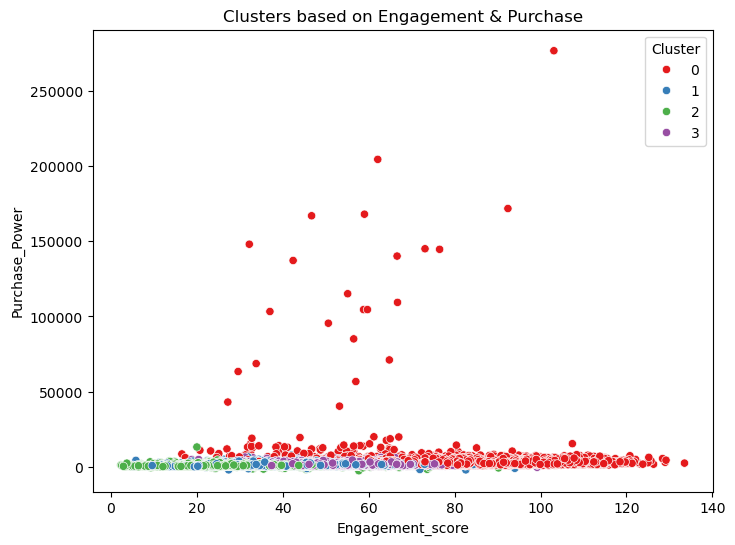

In [65]:
plt.figure(figsize = (8, 6))

sns.scatterplot(
    x = df['Engagement_score'],
    y = df['Purchase_Power'],
    hue = df['Cluster'],
    palette = 'Set1'
)
plt.title('Clusters based on Engagement & Purchase')
plt.show()

In [66]:
city_cols = [col for col in df.columns if col.startswith('City_')]

df['City'] = df[city_cols].idxmax(axis=1)

# Remove "City_" prefix
df['City'] = df['City'].str.replace('City_', '')

In [67]:
df.to_csv('customer_churn_cleaned_data.csv', index = False)
print('Saved')

Saved


In [68]:
df.to_csv(r"C:\Users\yoges\customer_churn_cleaned_data.csv", index=False)
print('saved')

saved


In [69]:
df.columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'High_Value_Customer', 'Engagement_score', 'Purchase_Power',
       'Recency_Score', 'Discount_sensitivity', 'Activity_Ratio',
       'Customer_Value', 'Engagement_Per_Purchase', 'Gender_Male',
       'Gender_Other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Japan', 'Country_UK', 'Country_USA',
       'City_Bangalore', 'City_Berlin', 'City_Birmingham', 'City_Brisbane',
       'City_Calgary', 'City_Chennai', 'City_Chicago', 'City_Cologne',
       'City

In [70]:
df['Churn_Label'] = df['Churned'].map({
    0 : 'Not Churned',
    1 : 'Churned'
})

In [71]:
df.to_csv(r"C:\Users\yoges\customer_churn_cleaned_data.csv", index=False)
print('saved')

saved


In [72]:
import os 
os.getcwd()

'C:\\Users\\yoges'

In [73]:
df.columns

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'High_Value_Customer', 'Engagement_score', 'Purchase_Power',
       'Recency_Score', 'Discount_sensitivity', 'Activity_Ratio',
       'Customer_Value', 'Engagement_Per_Purchase', 'Gender_Male',
       'Gender_Other', 'Country_Canada', 'Country_France', 'Country_Germany',
       'Country_India', 'Country_Japan', 'Country_UK', 'Country_USA',
       'City_Bangalore', 'City_Berlin', 'City_Birmingham', 'City_Brisbane',
       'City_Calgary', 'City_Chennai', 'City_Chicago', 'City_Cologne',
       'City

In [74]:
df[['City']].head(20)

,City
0,Marseille
1,Manchester
2,Vancouver
3,New York
4,Delhi
5,Tokyo
6,Berlin
7,Houston
8,Calgary
9,New York


In [75]:
feature_columns = X.columns.tolist()

In [76]:
feature_columns

['Age',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'High_Value_Customer',
 'Engagement_score',
 'Purchase_Power',
 'Recency_Score',
 'Discount_sensitivity',
 'Activity_Ratio',
 'Customer_Value',
 'Engagement_Per_Purchase',
 'Gender_Male',
 'Gender_Other',
 'Country_Canada',
 'Country_France',
 'Country_Germany',
 'Country_India',
 'Country_Japan',
 'Country_UK',
 'Country_USA',
 'City_Bangalore',
 'City_Berlin',
 'City_Birmingham',
 'City_Brisbane',
 'City_Calgary',
 'City_Chennai',
 'City_Chicago',
 'City_Cologne',
 'City_Delhi',
 'City_Frankfurt',
 'City_Glasgow',
 'City_Hamburg',
 'City_H

In [77]:
import joblib

In [78]:
joblib.dump(rf, 'churn_model.pkl')

joblib.dump(cluster_scaler, 'cluster_scaler.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(imputer, 'imputer.pkl')

joblib.dump(cluster_features, 'cluster_features.pkl')

joblib.dump(feature_columns, 'feature_columns.pkl')

joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [79]:
import os

[f for f in os.listdir() if f.endswith('.pkl')]

['churn_model.pkl',
 'cluster_features.pkl',
 'cluster_scaler.pkl',
 'demand_model.pkl',
 'feature_columns.pkl',
 'house_price_model.pkl',
 'imputer.pkl',
 'kmeans_model.pkl',
 'model.pkl',
 'model_columns.pkl',
 'pricing_model.pkl',
 'scaler.pkl',
 'walmart_sales_model.pkl']